*Synaptic biophysics* day 3


In [1]:
# Imports
import matplotlib.pyplot as plt
import numpy as np

Plotting Functions

In [2]:
# show the timing / density of the input trains
def my_illus_trains(pars, train1, train2, show=False):
  """
  Illustration of the spike train

  Args:
    pars  : parameters dictionary
    train1 : spike train
    train2 : spike train

  Returns:
    plot of spike train
  """
  
  plt.subplot(2,2,3)

  #from GPT5

  #eventplot takes a list of spike indices for each train. Multiply by dt to convert to spike times
  positions1 = [list(np.nonzero(row)[0]*pars['dt']) for row in train1]
  positions2 = [list(np.nonzero(row)[0]*pars['dt']) for row in train2]
    
  plt.eventplot(positions1, color='g', lineoffsets = 1)
  plt.eventplot(positions2, color='r', lineoffsets = -1)
    
  plt.xlabel('Time (ms)')
  plt.ylabel('Inputs (green E, red I)')
  #plt.legend(loc=[.8, 0.68])
  if show:
    plt.show()

In [18]:
def my_illus_gslow(t_R, impulse_R, train, gE, show=False):
  
  plt.figure(figsize=(9, 9))
  plt.subplot(2,2,1)

  plt.plot(t_R, impulse_R, 'r', lw=1.,
           label='Hybrid fast and slow synaptic conductance', zorder=2)

  plt.xlabel('Time (ms)')
  plt.ylabel('G (nS)')
  plt.legend(loc=[0.3, 0.68])
  
  plt.subplot(2,2,2)
  plt.plot(pars['range_t'], gE[:train.size], 'black', lw=1.,
           label='Slow Synaptic current in response to trains', zorder=2)   #truncate at the end of the train 
  plt.plot(pars['range_t'], -train, 'green', lw=1.,
           label='sum of trains', zorder=2)
  plt.xlabel('Time (ms)')
  plt.ylabel('G (nS)')
  plt.legend(loc=[1.1, 0.68])

  #plt.tight_layout()
  if show:
      plt.show()


In [4]:
def my_illus_LIFSYN(pars, v_fmp, v, show=False):
  """
  Illustration of Free Membrane Potential (if there were no spikes, just the input) and membrane voltage with spikes

  Args:
    pars  : parameters dictionary
    v_fmp : free membrane potential, mV
    v     : membrane voltage, mV

  Returns:
    plot of membrane voltage and FMP, alongside with the spiking threshold
    and the mean FMP (dashed lines)
  """

  #plt.figure(figsize=(7, 5))
  plt.subplot(2,2,4)
  plt.plot(pars['range_t'], v_fmp, 'r', lw=1.,
           label='Free mem. pot.', zorder=2)
  plt.plot(pars['range_t'], v, 'b', lw=1.,
           label='True mem. pot', zorder=1, alpha=0.7)
  plt.axhline(pars['V_th'], 0, 1, color='k', lw=2., ls='--',
              label='Spike Threshold', zorder=1)
  plt.axhline(np.mean(v_fmp), 0, 1, color='r', lw=2., ls='--',
              label='Mean Free Mem. Pot.', zorder=1)
  plt.xlabel('Time (ms)')
  plt.ylabel('V (mV)')
  plt.legend(loc=[.8, 0.68])
  if show:
      plt.show()

In [5]:
def Poisson_generator(pars, rate, n, myseed=False):
  """
  Generates poisson trains

  Args:
    pars       : parameter dictionary
    rate       : noise amplitute [Hz]
    n          : number of indepednent Poisson trains
    myseed     : random seed. int or Boolean

  Returns:
    pre_spike_train : spike train matrix, ith row represents whether
                      there is a spike in ith spike train over time
                      (1 if spike, 0 otherwise)
  """

  # Retrieve simulation parameters
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # set random seed
  if myseed:
      np.random.seed(seed=myseed)
  else:
      np.random.seed()

  # generate matrix of uniformly distributed random variables
  u_rand = np.random.rand(n, Lt)

  # generate Poisson train
  poisson_train = 1. * (u_rand < rate * (dt / 1000.))

  return poisson_train


Parameters for the simulation of LIF neuron

In [6]:
def default_pars(**kwargs):
  pars = {}

  ### typical neuron parameters###
  pars['V_th'] = -50.    # spike threshold [mV] - was -55 mV
  pars['V_reset'] = -75. # reset potential [mV]
  pars['tau_m'] = 10.    # membrane time constant [ms]
  pars['g_L'] = 10.      # leak conductance [nS]
  pars['V_init'] = -65.  # initial potential [mV]
  pars['E_L'] = -75.     # leak reversal potential [mV]
  pars['tref'] = 2.      # refractory time (ms)

  ### simulation parameters ###
  pars['T'] = 4000.  # Total duration of simulation [ms]
  pars['dt'] = .1   # Simulation time step [ms]

  ### external parameters if any ###
  for k in kwargs:
    pars[k] = kwargs[k]

  pars['range_t'] = np.arange(0, pars['T'], pars['dt'])  # Vector of discretized time points [ms]

  return pars

In [10]:
def slowConductance (taus=[1,1,1], amps=[0,0,0], dt=0.1):
    # provide a digitised synaptic current for convolution
    # returns Zero by default

    # make an array long enough
    # take the greatest tau
    longest = max(taus)

    # use 5* tau to get 99% of decay
    t_G_Slow = np.arange(0, 5 * longest, step=dt)

    #print (slowCond)
    
    #digitise
    G_slow = amps[0] * np.exp(-t_G_Slow/taus[0]) + amps[1] * np.exp(-t_G_Slow/taus[1]) + amps[2] * np.exp(-t_G_Slow/taus[2])
    
    return t_G_Slow, G_slow

In [21]:
# @markdown Execute this cell to get a function for conductance-based LIF neuron (run_LIF_cond)

def run_LIF_cond(pars, I_inj, pre_spike_train_ex, pre_spike_train_in, show):
  """
  Conductance-based LIF dynamics

  Args:
    pars               : parameter dictionary
    I_inj              : injected current [pA]. The injected current here
                         can be a value or an array
    pre_spike_train_ex : spike train input from presynaptic excitatory neuron
    pre_spike_train_in : spike train input from presynaptic inhibitory neuron

  Returns:
    rec_spikes         : spike times
    rec_v              : membrane potential
    gE                 : postsynaptic excitatory conductance
    gI                 : postsynaptic inhibitory conductance

  """

  # Retrieve parameters
  V_th, V_reset = pars['V_th'], pars['V_reset']
  tau_m, g_L = pars['tau_m'], pars['g_L']
  V_init, E_L = pars['V_init'], pars['E_L']
  gE_bar, gI_bar = pars['gE_bar'], pars['gI_bar']
  VE, VI = pars['VE'], pars['VI']
  tau_syn_I = pars['tau_syn_I']
  taus_syn_E = pars['taus_syn_E']
  amps_syn_E = pars['amps_syn_E']
  tref = pars['tref']
  dt, range_t = pars['dt'], pars['range_t']
  Lt = range_t.size

  # Initialize
  tr = 0.
  v = np.zeros(Lt)
  v[0] = V_init
  gE = np.zeros(Lt)
  gI = np.zeros(Lt)
  Iinj = I_inj * np.ones(Lt)  # ensure Iinj has length Lt

  if pre_spike_train_ex.max() == 0:        #no spikes
    pre_spike_train_ex_total = np.zeros(Lt)
  else:
    pre_spike_train_ex_total = pre_spike_train_ex.sum(axis=0) * np.ones(Lt)

  if pre_spike_train_in.max() == 0:
    pre_spike_train_in_total = np.zeros(Lt)
  else:
    pre_spike_train_in_total = pre_spike_train_in.sum(axis=0) * np.ones(Lt)

  # calculate the shape of the slow synaptic impulse response (kernel). 
  # these should be set as parameters
  t_slow, g_slow = slowConductance(taus_syn_E, amps_syn_E, dt=0.1) 

  # convolve globally, not per synapse.
  gE = np.convolve(pre_spike_train_ex_total, g_slow) * pars['gE_bar']

  #show the slow currents and relation to   
  if show == True:
    my_illus_gslow (t_slow, g_slow, pre_spike_train_ex_total, gE, show=False)
  else:
    None
  
  # simulation
  rec_spikes = []  # recording spike times
  for it in range(Lt - 1):
    if tr > 0:
      v[it] = V_reset
      tr = tr - 1
    elif v[it] >= V_th:  # reset voltage and record spike event
      rec_spikes.append(it)
      v[it] = V_reset
      tr = tref / dt

    # update the synaptic conductance
    # for slow excitatory conductances this is more sophisticated, we do not need to update gE for each step
    # gE was created in full above
    # first term is the decrement, second term is the instant peak of any synaptic input
    
    # fast synaptic currents  
    #gE[it + 1] = gE[it] - (dt / tau_syn_E) * gE[it] + gE_bar * pre_spike_train_ex_total[it + 1]
    gI[it + 1] = gI[it] - (dt / tau_syn_I) * gI[it] + gI_bar * pre_spike_train_in_total[it + 1]

    # calculate the increment of the membrane potential
    dv = (dt / tau_m) * (-(v[it] - E_L) \
                         - (gE[it + 1] / g_L) * (v[it] - VE) \
                         - (gI[it + 1] / g_L) * (v[it] - VI) + Iinj[it] / g_L)

    # update membrane potential
    v[it+1] = v[it] + dv

  rec_spikes = np.array(rec_spikes) * dt

  return v, rec_spikes, gE, gI


Main Code

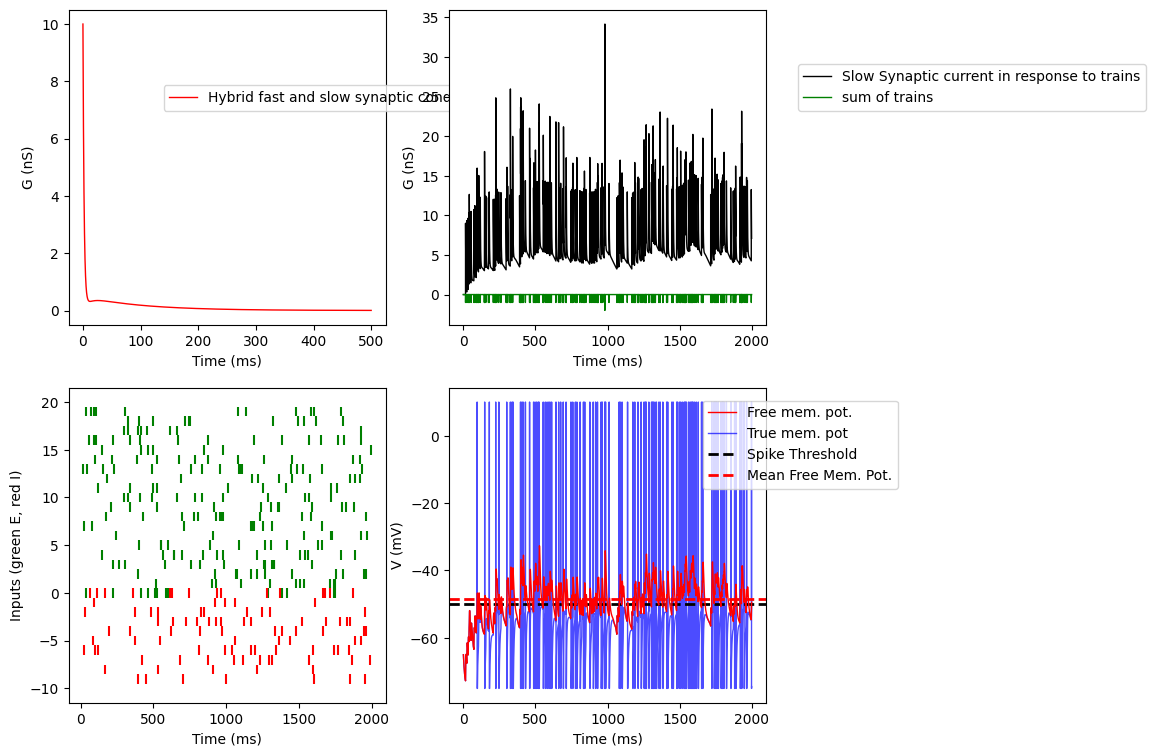

In [148]:
# Get default parameters
pars = default_pars(T=2000.)

# Add parameters
# excitatory
pars['gE_bar'] = .9    # [nS] was 2.4   1 receptor is 25 pS
pars['VE'] = 0.         # [mV] excitatory reversal potential
pars['taus_syn_E'] = [2., 10., 100.]  # [ms]
pars['amps_syn_E'] = [10, -0.5, 0.5] # unitless - fast decay, slow rise and slow decay
#pars['amps_syn_E'] = [1, 0, 0] # unitless - single fast decay
#pars['amps_syn_E'] = [.5, 0, .5] # unitless - fast decay and slow decay

# inhibitory
pars['gI_bar'] = .6      # [nS]
pars['VI'] = -80.       # [mV] inhibitory reversal potential
pars['tau_syn_I'] = 40.  # [ms]

pars['N_I'] = 10         # Number of inhibitory synapses
pars['N_E'] = 20          # Number of excitatory synapses
pars['r_I'] = 5.         # Rate of inhibitory input [Hz]
pars['r_E'] = 5.6        # Number of excitatory input [Hz]

# Generate presynaptic spike trains
pre_spike_train_ex = Poisson_generator(pars, pars['r_E'], n=pars['N_E'])
pre_spike_train_in = Poisson_generator(pars, pars['r_I'], n=pars['N_I'])

# Simulate conductance-based LIF model
# no injected current
v, rec_spikes, gE, gI = run_LIF_cond(pars, 0, pre_spike_train_ex,
                                     pre_spike_train_in, show = True)

# Show spikes more clearly by setting voltage high
dt, range_t = pars['dt'], pars['range_t']
if rec_spikes.size:
  sp_num = (rec_spikes / dt).astype(int) - 1
  v[sp_num] = 10   # draw nicer spikes


# Temporarily remove the threshold 
original_V_th = pars['V_th'] 
pars['V_th'] = 1e3

# # Calculate FMP
v_fmp, _, _, _ = run_LIF_cond(pars, 0, pre_spike_train_ex, pre_spike_train_in, show = False)

#reset to original threshold for display
pars['V_th'] = original_V_th

# train inputs as a separate graph
my_illus_trains(pars, pre_spike_train_ex, pre_spike_train_in)

#with plt.xkcd():
my_illus_LIFSYN(pars, v_fmp, v)

plt.show()
